In [28]:
import numpy as np
import pandas as pd
import missingno as msno

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [9]:
df = pd.read_csv('data/king_county_data.csv')
df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0.0,0.0,3,8,...,0.0,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0.0,0.0,3,8,...,0.0,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0.0,0.0,3,7,...,0.0,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,NaN,0.0,3,8,...,0.0,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0


In [10]:
# To check for space, odd characters, or capitals in column names
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='object')

In [11]:
# To check duplicates in columns
df.duplicated().value_counts()


False    21597
Name: count, dtype: int64

In [12]:
# To check data type in each column
df.dtypes


id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
date              object
price            float64
dtype: object

In [13]:
# check the format of date
type(df["date"][0])
# change the format of date to datetime with format %Y/%m/%d
df["date"] = pd.to_datetime(df["date"], format='mixed')
type(df["date"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [18]:
df['view'].unique()

array([ 0., nan,  3.,  4.,  2.,  1.])

In [19]:
# Fill NaNs in view with median view per zipcode
zip_view = df.groupby('zipcode')['view'].median()
df['view'] = df['view'].fillna(df['zipcode'].map(zip_view))
df['view'] = df['view'].round().astype(int)

In [20]:
df.dtypes

id                        int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront              float64
view                      int64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
date             datetime64[ns]
price                   float64
dtype: object

In [21]:
df.isnull().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view                0
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
dtype: int64

In [22]:
# add a column to the df for the house age
df['house_age'] = 2026 - df['yr_built']

In [23]:
# display number of missing values per column
df.isna().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view                0
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
house_age           0
dtype: int64

<Axes: >

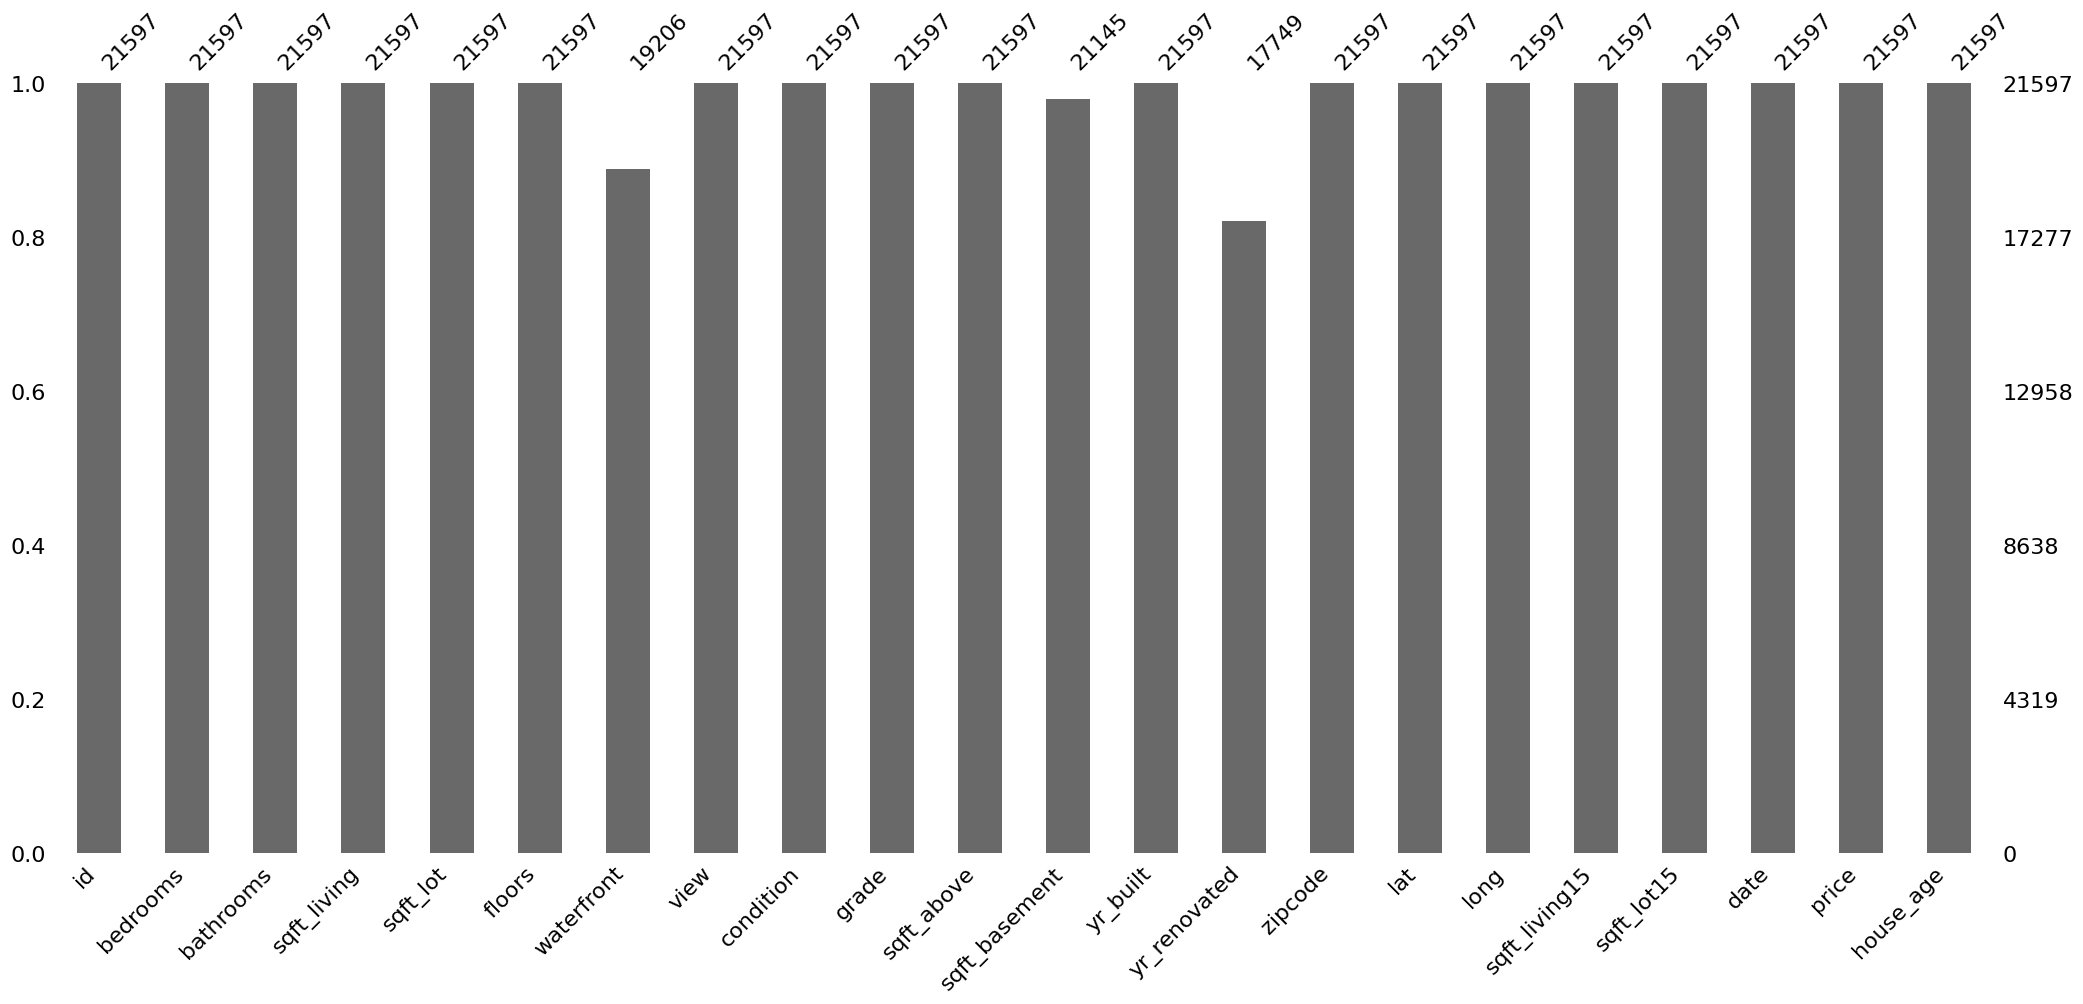

In [24]:
# plotting percentage of missing values per column
msno.bar(df)

<Axes: >

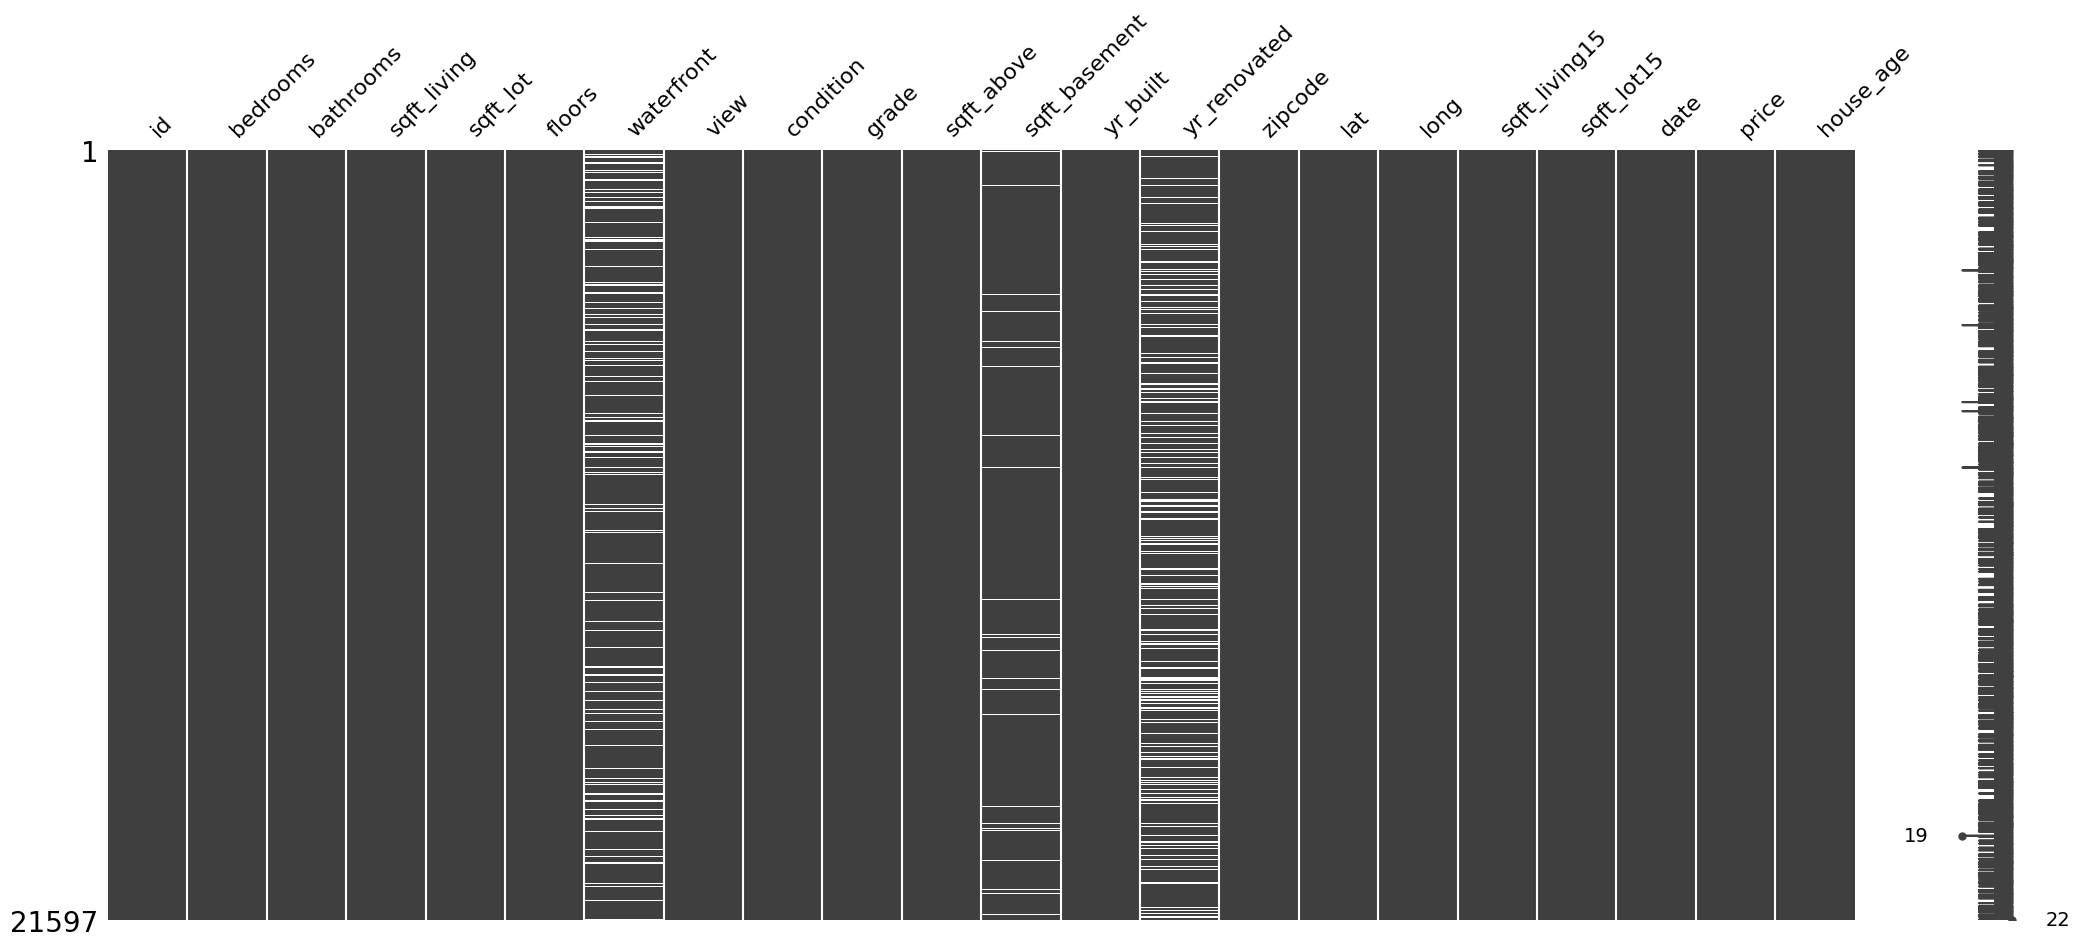

In [25]:
msno.matrix(df)

In [26]:
print(f"numbers of rows : {df.shape[0]}")
print(
    f"missing values in basement : {round(df.sqft_basement.isna().sum() / df.shape[0] * 100, 2)} %"
)
print(
    f"missing values in year renovated : {round(df.yr_renovated.isna().sum() / df.shape[0] * 100, 2)} %"
)
print(
    f"missing values in water front : {round(df.waterfront.isna().sum() / df.shape[0] * 100, 2)} %"
)

numbers of rows : 21597
missing values in basement : 2.09 %
missing values in year renovated : 17.82 %
missing values in water front : 11.07 %


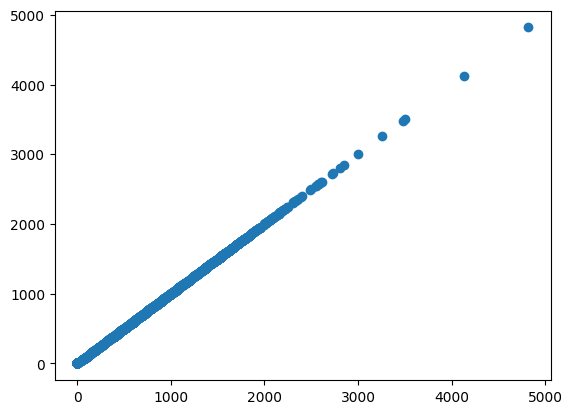

In [29]:
# app 1: drop missing vals since they are only 2% of the whole data
# df = df.dropna(subset=['sqft_basement']) 

# app 2: interpolate the missing values according to sqft_living - sqft-above, a perfect linear relation is seen
plt.scatter(df['sqft_living'] - df['sqft_above'], df['sqft_basement'])

In [30]:
# Check how perfect is the relation for all houses (0 implies a perfect relation)
check = df['sqft_living'] - (df['sqft_above'] + df['sqft_basement'])
print(check.abs().max())

0.0


In [ ]:
# Now we apply this rule to missing vals in sqft_basement
mask_bsmnt = df['sqft_basement'].isna()

df.loc[mask_bsmnt, 'sqft_basement'] = (
    df.loc[mask_bsmnt, 'sqft_living'] - df.loc[mask_bsmnt, 'sqft_above']
)

df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_age
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0,3,7,...,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,71
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0,3,7,...,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,75
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0,3,6,...,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,93
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0,5,7,...,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,61
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0,3,8,...,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0.0,0,3,8,...,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0,17
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0.0,0,3,8,...,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0,12
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0.0,0,3,7,...,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0,17
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,NaN,0,3,8,...,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0,22


In [32]:
# To fill NaNs in waterfront

# Split data to training and test data sets
df_known = df[df['waterfront'].notna()]
df_missing = df[df['waterfront'].isna()]

# Features and target
X_train = df_known[['lat', 'long']]
y_train = df_known['waterfront']

X_missing = df_missing[['lat', 'long']]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_missing_scaled = scaler.transform(X_missing)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')
knn.fit(X_train_scaled, y_train)

# Predict missing values
predicted = knn.predict(X_missing_scaled)

# Fill back into dataframe
df.loc[df['waterfront'].isna(), 'waterfront'] = predicted

# Convert dtype to int
df['waterfront'] = df['waterfront'].astype(int)
df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_age
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,...,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,71
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,75
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,93
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,61
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,...,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0,0,3,8,...,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0,17
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0,0,3,8,...,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0,12
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0,0,3,7,...,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0,17
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,0,0,3,8,...,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0,22


In [33]:

scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
print("Accuracy:", scores.mean())

Accuracy: 0.992814750735272


In [34]:
# to find strange values in yr_renovated
df[df['yr_renovated'] > 2026]
# to remove the last 0 from the yr_renovated
df.loc[df['yr_renovated'] > 2026, 'yr_renovated'] //= 10
df.dtypes

#df['yr_renovated']

id                        int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
date             datetime64[ns]
price                   float64
house_age                 int64
dtype: object

In [35]:
# To get the ranges for these three columns as features with no NaNs
print(df['yr_built'].max(), df['yr_built'].min())
print(df['grade'].max(), df['grade'].min())
print(df['condition'].max(), df['condition'].min())

2015 1900
13 3
5 1


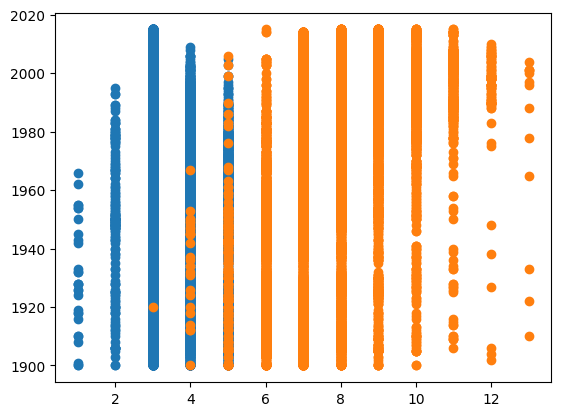

In [36]:
# No relation was seen between grade/condition and yr_built
import matplotlib.pyplot as plt
plt.scatter(df['condition'], df['yr_built'])
plt.scatter(df['grade'], df['yr_built'])

In [37]:
# To fill NaNs in yr_renovated
# Approach: if yr_built < threshold and grade > threshold and condition > threshold, the house has been renovated
# Then, the NaN should be replaced by yr_renovated obtained through learning 

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

features = ['yr_built', 'grade', 'condition']

# Split dataset
df_known = df[df['yr_renovated'].notna()].copy()
df_missing = df[df['yr_renovated'].isna()].copy()

# Classification: Was the house renovated?
X_train_clf = df_known[features]
y_train_clf = (df_known['yr_renovated'] > 0).astype(int)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train_clf, y_train_clf)

# Predict class (0 = not renovated, 1 = renovated)
X_missing = df_missing[features]
predicted_class = clf.predict(X_missing)

# Regression: Year of renovation
df_renov = df_known[df_known['yr_renovated'] > 0]

X_train_reg = df_renov[features]
y_train_reg = df_renov['yr_renovated']

reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(X_train_reg, y_train_reg)

# Predict renovation year for missing rows
predicted_years = reg.predict(X_missing)

# Fill NaNs
filled_values = [
    int(year) if cls == 1 else 0
    for cls, year in zip(predicted_class, predicted_years)
]

df.loc[df['yr_renovated'].isna(), 'yr_renovated'] = filled_values

# Add column 'if_renovated'
df['if_renovated'] = (df['yr_renovated'] > 0).astype(int)

# Change dtype of yr_renovated
df = df.astype({"yr_renovated": int})

df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_age,if_renovated
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,...,0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,71,0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,1991,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,75,1
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,93,0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,61,0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,...,0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0,0,3,8,...,0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0,17,0
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0,0,3,8,...,0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0,12,0
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0,0,3,7,...,0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0,17,0
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,0,0,3,8,...,0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0,22,0


In [38]:
# Save the cleaned df as a new dataframe for further use
df.to_csv('df_cleaned.csv', index=False)
df2 = pd.read_csv('df_cleaned.csv')
df2

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_age,if_renovated
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,...,0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,71,0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,1991,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,75,1
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,93,0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,61,0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,...,0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0,0,3,8,...,0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0,17,0
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0,0,3,8,...,0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0,12,0
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0,0,3,7,...,0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0,17,0
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,0,0,3,8,...,0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0,22,0


<Axes: >

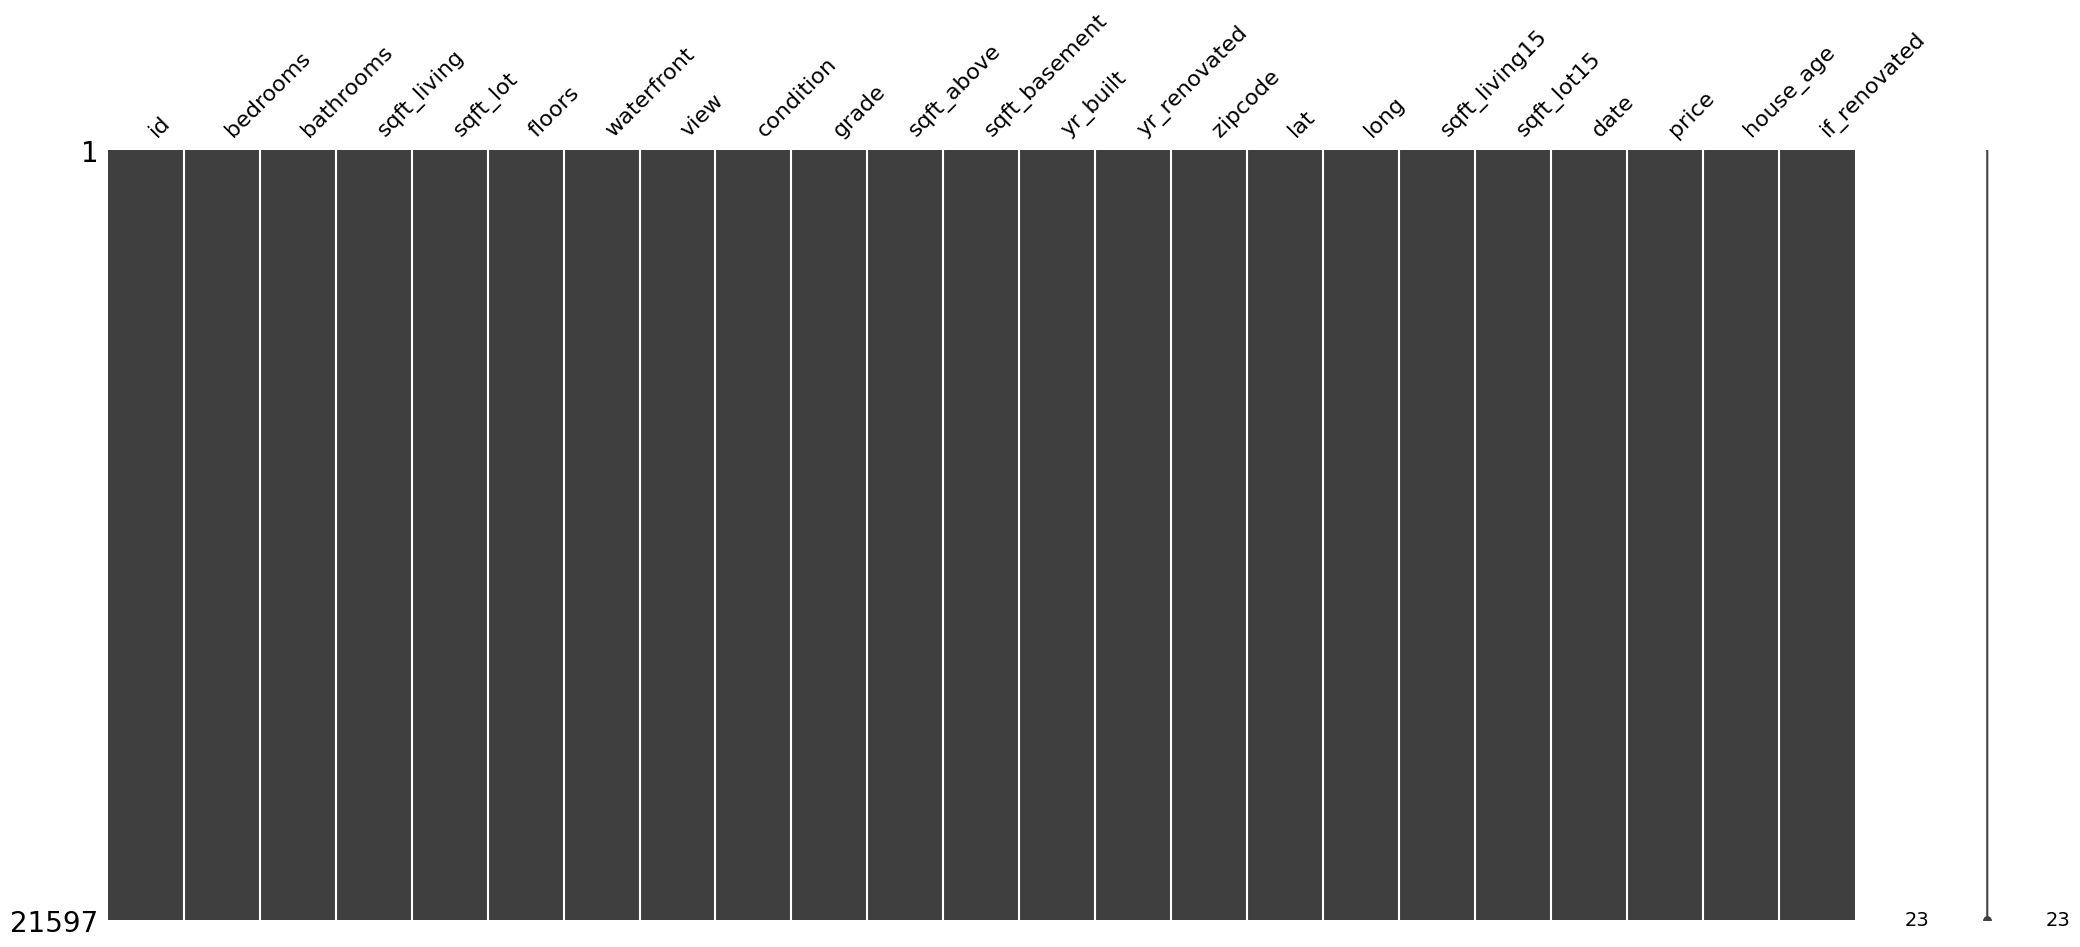

In [39]:
# check the cleaned df for NaNs
msno.matrix(df2)

In [ ]:
# Now the data is clean and ready for further analysis